# Laboratório 02 — Experimentando o ACO

**Objetivo:** compreender, por meio de experimentos, como os principais parâmetros do ACO influenciam a busca por uma boa rota.

O código-base é o mesmo do Laboratório 01 (sem alterações nas funções). O que muda em cada experimento são os valores de `ALPHA`, `BETA`, `TAXA_EVAPORACAO` e `NUM_FORMIGAS`.

Para que a comparação entre os experimentos seja justa, fixamos uma semente aleatória (`random.seed`) antes de cada execução — assim, a diferença observada nos resultados vem dos parâmetros, e não apenas da sorte de cada rodada.


In [1]:
%matplotlib inline

## 1. Código-base (igual ao Laboratório 01)

In [2]:
# 1. Importação das bibliotecas
import numpy as np
import random
import matplotlib.pyplot as plt

In [3]:
# 2. Representação da rede
CUSTOS = np.array([
    [0, 2, 4, np.inf, np.inf, np.inf],
    [2, 0, 1, 5, np.inf, np.inf],
    [4, 1, 0, 2, 3, np.inf],
    [np.inf, 5, 2, 0, 1, 4],
    [np.inf, np.inf, 3, 1, 0, 2],
    [np.inf, np.inf, np.inf, 4, 2, 0]
])

ORIGEM = 0
DESTINO = 5

In [4]:
# ============================================================
# PARÂMETROS DO EXPERIMENTO
# ============================================================

NUM_FORMIGAS = 20
NUM_ITERACOES = 50

ALPHA = 1.0
BETA = 2.0

TAXA_EVAPORACAO = 0.5
Q = 100

In [5]:
# Matriz de feromônio inicial
feromonio = np.ones_like(CUSTOS, dtype=float)
feromonio[CUSTOS == np.inf] = 0

In [6]:
def obter_vizinhos(no):

    vizinhos = []

    for proximo in range(len(CUSTOS)):

        if proximo != no and CUSTOS[no][proximo] != np.inf:
            vizinhos.append(proximo)

    return vizinhos

In [7]:
def escolher_proximo(no_atual, visitados):

    vizinhos = obter_vizinhos(no_atual)

    candidatos = [
        no for no in vizinhos
        if no not in visitados
    ]

    if not candidatos:
        return None

    atratividades = []

    for proximo in candidatos:

        fer = feromonio[no_atual][proximo]
        custo = CUSTOS[no_atual][proximo]

        atratividade = (
            fer ** ALPHA
            * (1 / custo) ** BETA
        )

        atratividades.append(atratividade)

    soma = sum(atratividades)

    probabilidades = [
        valor / soma
        for valor in atratividades
    ]

    return random.choices(
        candidatos,
        weights=probabilidades,
        k=1
    )[0]

In [8]:
def construir_rota():

    rota = [ORIGEM]
    atual = ORIGEM

    while atual != DESTINO:

        proximo = escolher_proximo(
            atual,
            rota
        )

        if proximo is None:
            return None

        rota.append(proximo)
        atual = proximo

    return rota

In [9]:
def calcular_custo(rota):

    total = 0

    for i in range(len(rota) - 1):

        origem = rota[i]
        destino = rota[i + 1]

        total += CUSTOS[origem][destino]

    return total

In [10]:
def depositar_feromonio(rota, custo):

    deposito = Q / custo

    for i in range(len(rota) - 1):

        origem = rota[i]
        destino = rota[i + 1]

        feromonio[origem][destino] += deposito

In [11]:
def evaporar_feromonio():

    global feromonio

    feromonio *= (1 - TAXA_EVAPORACAO)
    feromonio[CUSTOS == np.inf] = 0

## 2. Função auxiliar para rodar um experimento

As funções acima são exatamente as do Laboratório 01. Para não repetir o mesmo laço de repetição 9 vezes, colocamos o "ciclo do ACO" dentro de uma função. A lógica interna (avaliar, evaporar, depositar) é idêntica à do Laboratório 01 — só reorganizamos para reaproveitar entre os experimentos.

In [12]:
def rodar_experimento(nome, seed=42):

    global feromonio, melhor_rota, melhor_custo, historico

    random.seed(seed)
    np.random.seed(seed)

    # reinicia o feromônio para cada experimento começar do zero
    feromonio = np.ones_like(CUSTOS, dtype=float)
    feromonio[CUSTOS == np.inf] = 0

    melhor_rota = None
    melhor_custo = float("inf")
    historico = []

    formigas_sem_rota = 0
    iteracao_do_melhor = None

    for iteracao in range(NUM_ITERACOES):

        rotas = []

        for _ in range(NUM_FORMIGAS):

            rota = construir_rota()

            if rota is None:
                formigas_sem_rota += 1
                continue

            custo = calcular_custo(rota)
            rotas.append((rota, custo))

            if custo < melhor_custo:
                melhor_custo = custo
                melhor_rota = rota.copy()
                iteracao_do_melhor = iteracao

        evaporar_feromonio()

        for rota, custo in rotas:
            depositar_feromonio(rota, custo)

        historico.append(melhor_custo)

    print("\n========== RESULTADO DO EXPERIMENTO ==========")
    print("Experimento:", nome)
    print("Número de formigas:", NUM_FORMIGAS)
    print("Número de iterações:", NUM_ITERACOES)
    print("ALPHA:", ALPHA)
    print("BETA:", BETA)
    print("Taxa de evaporação:", TAXA_EVAPORACAO)
    print("Melhor rota:", melhor_rota)
    print("Melhor custo:", melhor_custo)
    print("Iteração em que o melhor custo foi encontrado:", iteracao_do_melhor)
    print("Formigas que ficaram sem rota (None):", formigas_sem_rota)
    print("Feromônio máximo ao final:", round(feromonio.max(), 2))
    print("Feromônio médio nas conexões existentes:", round(feromonio[CUSTOS != np.inf].mean(), 2))

    plt.figure(figsize=(8, 4))
    plt.plot(historico)
    plt.xlabel("Iteração")
    plt.ylabel("Melhor custo")
    plt.title(f"Convergência — {nome}")
    plt.grid()
    plt.show()

## 3. Experimento 1 — Influência do ALPHA

Baseline: ALPHA=1.0 e BETA=2.0 (referência para os demais experimentos).

In [13]:
ALPHA = 1.0
BETA = 2.0
TAXA_EVAPORACAO = 0.5
NUM_FORMIGAS = 20
NUM_ITERACOES = 50


========== RESULTADO DO EXPERIMENTO ==========
Experimento: Baseline (ALPHA=1.0)
Número de formigas: 20
Número de iterações: 50
ALPHA: 1.0
BETA: 2.0
Taxa de evaporação: 0.5
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0
Iteração em que o melhor custo foi encontrado: 0
Formigas que ficaram sem rota (None): 0
Feromônio máximo ao final: 500.0
Feromônio médio nas conexões existentes: 104.17


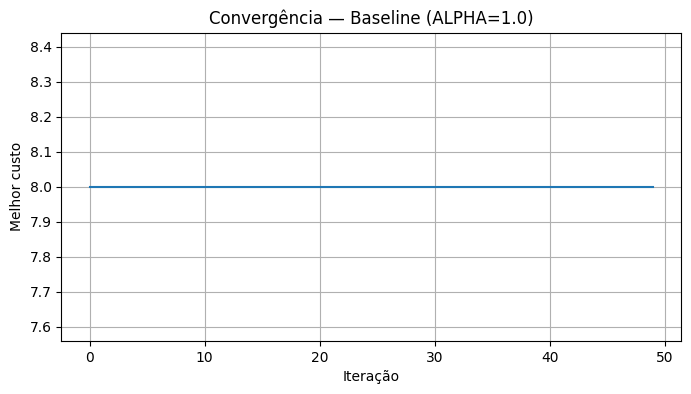

In [14]:
rodar_experimento("Baseline (ALPHA=1.0)")

Agora com ALPHA = 0.1 (mantendo os demais parâmetros).

In [15]:
ALPHA = 0.1
BETA = 2.0
TAXA_EVAPORACAO = 0.5
NUM_FORMIGAS = 20
NUM_ITERACOES = 50


========== RESULTADO DO EXPERIMENTO ==========
Experimento: ALPHA=0.1
Número de formigas: 20
Número de iterações: 50
ALPHA: 0.1
BETA: 2.0
Taxa de evaporação: 0.5
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0
Iteração em que o melhor custo foi encontrado: 0
Formigas que ficaram sem rota (None): 2
Feromônio máximo ao final: 392.52
Feromônio médio nas conexões existentes: 90.9


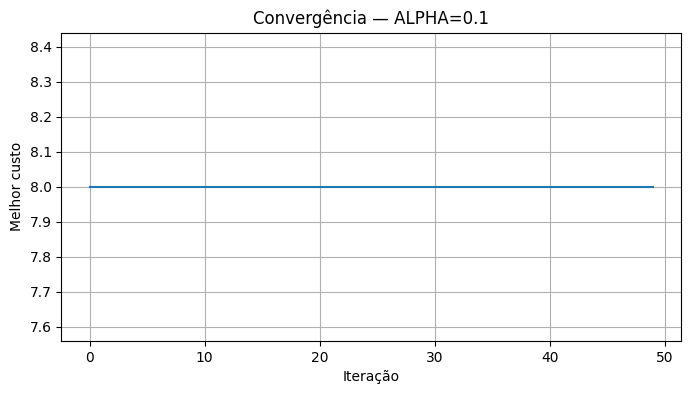

In [16]:
rodar_experimento("ALPHA=0.1")

Agora com ALPHA = 5.0.

In [17]:
ALPHA = 5.0
BETA = 2.0
TAXA_EVAPORACAO = 0.5
NUM_FORMIGAS = 20
NUM_ITERACOES = 50


========== RESULTADO DO EXPERIMENTO ==========
Experimento: ALPHA=5.0
Número de formigas: 20
Número de iterações: 50
ALPHA: 5.0
BETA: 2.0
Taxa de evaporação: 0.5
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0
Iteração em que o melhor custo foi encontrado: 0
Formigas que ficaram sem rota (None): 0
Feromônio máximo ao final: 500.0
Feromônio médio nas conexões existentes: 104.17


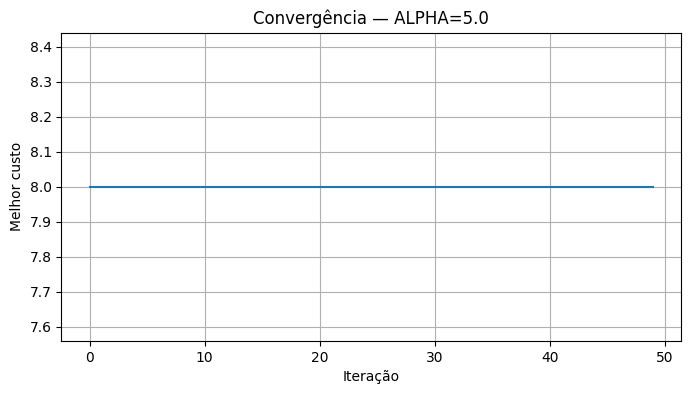

In [18]:
rodar_experimento("ALPHA=5.0")

## 4. Experimento 2 — Influência do BETA

Voltando para ALPHA = 1.0. Agora testamos BETA = 0.5.

In [19]:
ALPHA = 1.0
BETA = 0.5
TAXA_EVAPORACAO = 0.5
NUM_FORMIGAS = 20
NUM_ITERACOES = 50


========== RESULTADO DO EXPERIMENTO ==========
Experimento: BETA=0.5
Número de formigas: 20
Número de iterações: 50
ALPHA: 1.0
BETA: 0.5
Taxa de evaporação: 0.5
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0
Iteração em que o melhor custo foi encontrado: 0
Formigas que ficaram sem rota (None): 4
Feromônio máximo ao final: 500.0
Feromônio médio nas conexões existentes: 104.17


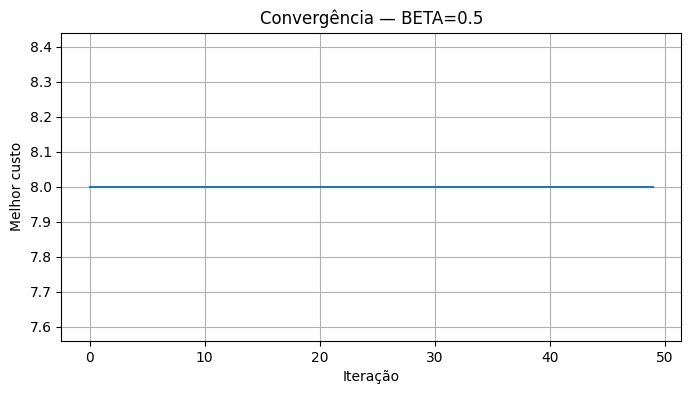

In [20]:
rodar_experimento("BETA=0.5")

Agora com BETA = 5.0.

In [21]:
ALPHA = 1.0
BETA = 5.0
TAXA_EVAPORACAO = 0.5
NUM_FORMIGAS = 20
NUM_ITERACOES = 50


========== RESULTADO DO EXPERIMENTO ==========
Experimento: BETA=5.0
Número de formigas: 20
Número de iterações: 50
ALPHA: 1.0
BETA: 5.0
Taxa de evaporação: 0.5
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0
Iteração em que o melhor custo foi encontrado: 0
Formigas que ficaram sem rota (None): 0
Feromônio máximo ao final: 500.0
Feromônio médio nas conexões existentes: 104.17


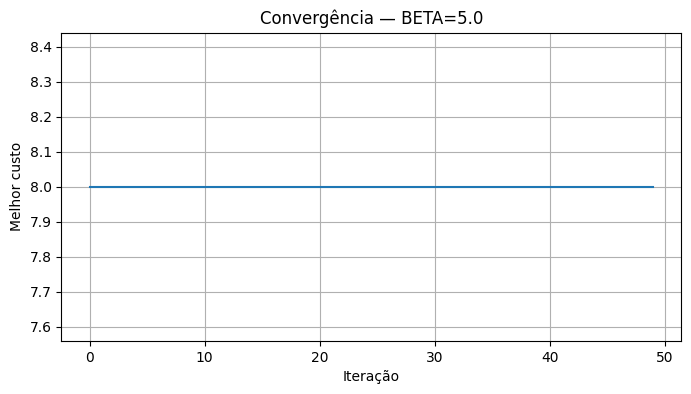

In [22]:
rodar_experimento("BETA=5.0")

## 5. Experimento 3 — Evaporação

Voltando para BETA = 2.0. Agora testamos TAXA_EVAPORACAO = 0.1.

In [23]:
ALPHA = 1.0
BETA = 2.0
TAXA_EVAPORACAO = 0.1
NUM_FORMIGAS = 20
NUM_ITERACOES = 50


========== RESULTADO DO EXPERIMENTO ==========
Experimento: EVAPORACAO=0.1
Número de formigas: 20
Número de iterações: 50
ALPHA: 1.0
BETA: 2.0
Taxa de evaporação: 0.1
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0
Iteração em que o melhor custo foi encontrado: 0
Formigas que ficaram sem rota (None): 0
Feromônio máximo ao final: 2486.51
Feromônio médio nas conexões existentes: 517.93


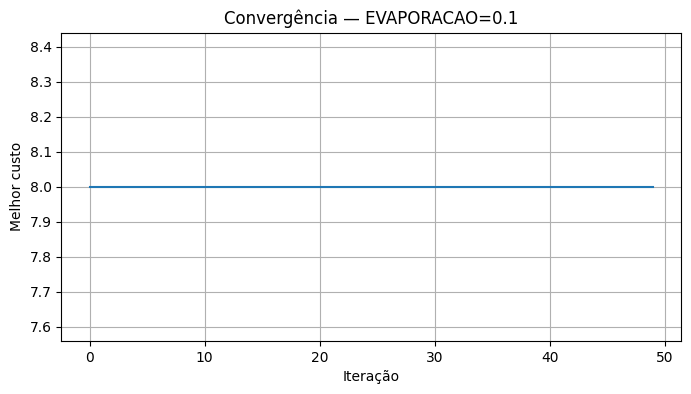

In [24]:
rodar_experimento("EVAPORACAO=0.1")

Agora com TAXA_EVAPORACAO = 0.9.

In [25]:
ALPHA = 1.0
BETA = 2.0
TAXA_EVAPORACAO = 0.9
NUM_FORMIGAS = 20
NUM_ITERACOES = 50


========== RESULTADO DO EXPERIMENTO ==========
Experimento: EVAPORACAO=0.9
Número de formigas: 20
Número de iterações: 50
ALPHA: 1.0
BETA: 2.0
Taxa de evaporação: 0.9
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0
Iteração em que o melhor custo foi encontrado: 0
Formigas que ficaram sem rota (None): 0
Feromônio máximo ao final: 277.78
Feromônio médio nas conexões existentes: 57.87


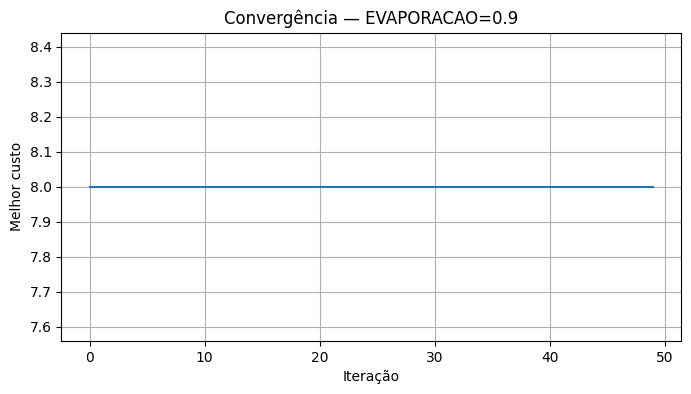

In [26]:
rodar_experimento("EVAPORACAO=0.9")

## 6. Experimento 4 — Número de formigas

Voltando para TAXA_EVAPORACAO = 0.5. Agora testamos NUM_FORMIGAS = 5.

In [27]:
ALPHA = 1.0
BETA = 2.0
TAXA_EVAPORACAO = 0.5
NUM_FORMIGAS = 5
NUM_ITERACOES = 50


========== RESULTADO DO EXPERIMENTO ==========
Experimento: FORMIGAS=5
Número de formigas: 5
Número de iterações: 50
ALPHA: 1.0
BETA: 2.0
Taxa de evaporação: 0.5
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0
Iteração em que o melhor custo foi encontrado: 0
Formigas que ficaram sem rota (None): 0
Feromônio máximo ao final: 125.0
Feromônio médio nas conexões existentes: 26.04


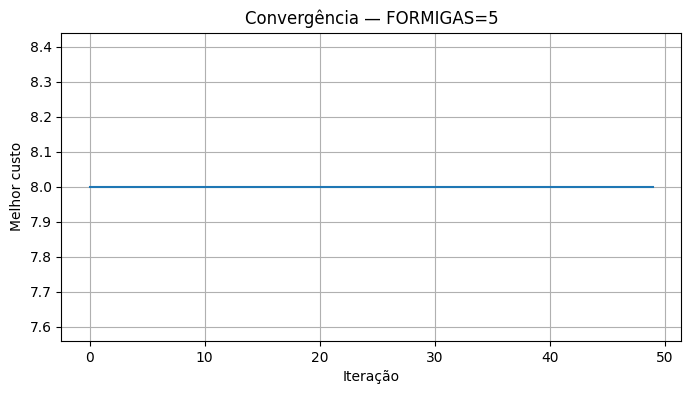

In [28]:
rodar_experimento("FORMIGAS=5")

Agora com NUM_FORMIGAS = 50.

In [29]:
ALPHA = 1.0
BETA = 2.0
TAXA_EVAPORACAO = 0.5
NUM_FORMIGAS = 50
NUM_ITERACOES = 50


========== RESULTADO DO EXPERIMENTO ==========
Experimento: FORMIGAS=50
Número de formigas: 50
Número de iterações: 50
ALPHA: 1.0
BETA: 2.0
Taxa de evaporação: 0.5
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0
Iteração em que o melhor custo foi encontrado: 0
Formigas que ficaram sem rota (None): 1
Feromônio máximo ao final: 1250.0
Feromônio médio nas conexões existentes: 260.42


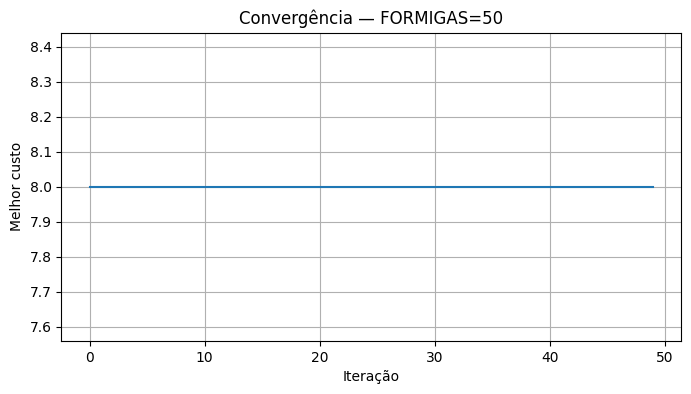

In [30]:
rodar_experimento("FORMIGAS=50")